# Neural Network (NN1) on MHAR Feature Set

**Purpose:** This notebook implements the shallow neural network architecture NN1 from Christensen, Siggaard, and Veliyev (2023) on the MHAR feature set for the EURO STOXX 50 index. The network has a single hidden layer with two neurons and serves as the simplest neural-network benchmark considered in the paper. The implementation below follows the paper as closely as possible, while also documenting two important practical departures made in this thesis: (i) the ensemble size and training budget are reduced because the full paper configuration is computationally expensive in this environment, and (ii) the model is re-estimated every 22 trading days in a rolling scheme, whereas the paper uses a fixed-window neural-network estimation. These deviations are highlighted explicitly in the relevant sections below.

## 1. Imports

We import the libraries required for data handling, numerical computation, and neural-network estimation. TensorFlow and Keras are used to define and train the NN1 architecture.

In [4]:
import os
import time
import warnings

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")


TensorFlow version: 2.16.2
Keras version: 3.10.0


## 2. Data Loading

We use the same `MALL.csv` data source as in the HAR, regularized, and tree-based benchmark notebooks so that the NN1 model is evaluated on the same target, predictors, and out-of-sample window.

In [7]:
MALL = pd.read_csv("/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Cleaned Data/MALL.csv")
MALL["Date"] = pd.to_datetime(MALL["Date"])
MALL = MALL.set_index("Date")

print(f"Sample period: {MALL.index[0].date()} to {MALL.index[-1].date()}")
print(f"Number of observations: {len(MALL)}")
display(MALL[["RVD", "RVW", "RVM", "RV_target"]].head())


Sample period: 1999-01-05 to 2020-08-06
Number of observations: 5489


,RVD,RVW,RVM,RV_target
Date,,,,
1999-01-05,0.000078,0.000093,0.000129,0.000058
1999-01-06,0.000058,0.000092,0.000123,0.000139
1999-01-07,0.000139,0.000102,0.000121,0.000108
1999-01-08,0.000108,0.000106,0.000112,0.000166
1999-01-11,0.000166,0.000110,0.000110,0.000115


## 3. Data Split

To remain directly comparable with the other MHAR notebooks, we use the same 70/10/20 split into training, validation, and test sets. The validation block is used for early stopping and ensemble selection.

In [10]:
n = len(MALL)
n_train = int(np.floor(0.70 * n))
n_val = int(np.floor(0.10 * n))
n_test = n - n_train - n_val

print(f"Total observations: {n}")
print(f"\nTraining:   {MALL.index[0].date()} to {MALL.index[n_train-1].date()} ({n_train} obs)")
print(f"Validation: {MALL.index[n_train].date()} to {MALL.index[n_train+n_val-1].date()} ({n_val} obs)")
print(f"Test:       {MALL.index[n_train+n_val].date()} to {MALL.index[-1].date()} ({n_test} obs)")


Total observations: 5489

Training:   1999-01-05 to 2014-02-26 (3842 obs)
Validation: 2014-02-27 to 2016-04-20 (548 obs)
Test:       2016-04-21 to 2020-08-06 (1099 obs)


## 4. Feature Set Construction and Standardization

Following the paper, we use the MHAR feature set consisting of daily, weekly, and monthly realized-volatility components. Both predictors and the target are standardized using moments from the training set only. Standardizing the target is convenient in neural-network training because it stabilizes optimization and makes the scale of the loss function easier to manage.

In [13]:
y = MALL["RV_target"].values
X_MHAR = MALL[["RVD", "RVW", "RVM"]].values

X_train = X_MHAR[:n_train]
X_val = X_MHAR[n_train:n_train + n_val]
X_test = X_MHAR[n_train + n_val:]

y_train = y[:n_train]
y_val = y[n_train:n_train + n_val]
y_test = y[n_train + n_val:]

X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0)
X_std = np.where(X_std == 0, 1.0, X_std)
y_mean = y_train.mean()
y_std = y_train.std()

X_scaled = (X_MHAR - X_mean) / X_std
y_scaled = (y - y_mean) / y_std

print("Feature set: RVD, RVW, RVM")
print(f"\nFull dataset:   X={X_scaled.shape}, y={y_scaled.shape}")
print(f"Training set:   X={X_scaled[:n_train].shape}, y={y_scaled[:n_train].shape}")
print(f"Validation set: X={X_scaled[n_train:n_train+n_val].shape}, y={y_scaled[n_train:n_train+n_val].shape}")
print(f"Test set:       X={X_scaled[n_train+n_val:].shape}, y={y_scaled[n_train+n_val:].shape}")
print("\nStandardization check on training sample:")
print(f"  X means: {X_scaled[:n_train].mean(axis=0).round(6)}")
print(f"  X stds:  {X_scaled[:n_train].std(axis=0).round(6)}")
print(f"  y mean:  {y_scaled[:n_train].mean():.6f}")
print(f"  y std:   {y_scaled[:n_train].std():.6f}")


Feature set: RVD, RVW, RVM

Full dataset:   X=(5489, 3), y=(5489,)
Training set:   X=(3842, 3), y=(3842,)
Validation set: X=(548, 3), y=(548,)
Test set:       X=(1099, 3), y=(1099,)

Standardization check on training sample:
  X means: [-0.  0. -0.]
  X stds:  [1. 1. 1.]
  y mean:  0.000000
  y std:   1.000000


## 5. NN1 Architecture

The paper's NN1 architecture is a shallow feed-forward network with a single hidden layer containing two neurons. We follow the paper in using Leaky ReLU activation with slope parameter `0.01`, Adam with learning rate `0.001`, Glorot normal initialization, and dropout with keep rate `0.8` (implemented as dropout rate `0.2`).

In [16]:
def build_NN1(input_dim=3, seed=None):
    if seed is not None:
        tf.random.set_seed(seed)

    initializer = keras.initializers.GlorotNormal(seed=seed)

    model = keras.Sequential([
        keras.Input(shape=(input_dim,)),
        layers.Dense(2, kernel_initializer=initializer, bias_initializer="zeros"),
        layers.LeakyReLU(negative_slope=0.01),
        layers.Dropout(rate=0.2),
        layers.Dense(1, kernel_initializer=initializer, bias_initializer="zeros", activation="linear")
    ])

    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss="mse")
    return model

test_model = build_NN1(input_dim=3, seed=0)
test_model.summary()
print("\nTotal trainable parameters should be 11.")


2026-03-23 08:48:37.375866: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-03-23 08:48:37.375964: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-03-23 08:48:37.375991: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-03-23 08:48:37.376811: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-23 08:48:37.377497: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 2)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11 (44.00 B)

 Trainable params: 11 (44.00 B)

 Non-trainable params: 0 (0.00 B)


Total trainable parameters should be 11.


## 6. Hyperparameters and Departures from the Paper

This section is where the thesis implementation departs most clearly from the reference paper. The paper trains `100` independent networks and averages the best `10`, uses up to `500` epochs, patience `100`, and applies a fixed-window neural-network estimation. In this thesis, we reduce the computational burden by using a smaller ensemble, fewer epochs, and a monthly rolling re-estimation frequency of `22` trading days. The latter is an extension relative to the paper: it allows the model to adapt over time, but it is not the exact estimation design used in the published study.

In [19]:
n_ensemble = 10
n_best = 3
max_epochs = 200
patience = 50
refit_freq = 22

print("Hyperparameter summary:")
print(f"  Ensemble size:      {n_ensemble} (paper: 100)")
print(f"  Best networks kept: {n_best} (paper: 10)")
print(f"  Max epochs:         {max_epochs} (paper: 500)")
print(f"  Patience:           {patience} (paper: 100)")
print(f"  Refit frequency:    every {refit_freq} trading days (paper: fixed window)")
print("  Learning rate:      0.001 (same as paper)")
print("  Dropout keep rate:  0.8 (same as paper)")
print("  Activation:         Leaky ReLU with slope 0.01 (same as paper)")
print("  Initializer:        Glorot normal (same as paper)")


Hyperparameter summary:
  Ensemble size:      10 (paper: 100)
  Best networks kept: 3 (paper: 10)
  Max epochs:         200 (paper: 500)
  Patience:           50 (paper: 100)
  Refit frequency:    every 22 trading days (paper: fixed window)
  Learning rate:      0.001 (same as paper)
  Dropout keep rate:  0.8 (same as paper)
  Activation:         Leaky ReLU with slope 0.01 (same as paper)
  Initializer:        Glorot normal (same as paper)


## 7. Rolling Window Estimation and Forecasting

The rolling forecast design keeps the train-plus-validation window length fixed and moves it through the test sample. Every `22` trading days, we retrain the ensemble on the current window, rank the networks by validation loss, retain the best-performing subset, and use their average prediction as the one-step-ahead forecast. This is a deliberate departure from the paper's fixed-window neural-network setup and is adopted to let the network incorporate more recent information without retraining every single day.

In [22]:
window_size = n_train + n_val
forecasts_NN1 = []
dates_test = []
best_models = None
last_refit = -refit_freq
n_refits = int(np.ceil(n_test / refit_freq))

start_time = time.time()

for i in range(n_test):
    if i - last_refit >= refit_freq:
        X_window = X_scaled[i:i + window_size]
        y_window = y_scaled[i:i + window_size]

        X_win_train = X_window[:-n_val]
        X_win_val = X_window[-n_val:]
        y_win_train = y_window[:-n_val]
        y_win_val = y_window[-n_val:]

        val_losses_window = []
        models_window = []

        for j in range(n_ensemble):
            early_stopping = EarlyStopping(
                monitor="val_loss",
                patience=patience,
                restore_best_weights=True,
                verbose=0
            )

            model = build_NN1(input_dim=X_scaled.shape[1], seed=j)
            model.fit(
                X_win_train, y_win_train,
                validation_data=(X_win_val, y_win_val),
                epochs=max_epochs,
                batch_size=len(X_win_train),
                callbacks=[early_stopping],
                verbose=0
            )
            val_loss = model.evaluate(X_win_val, y_win_val, verbose=0)
            val_losses_window.append(val_loss)
            models_window.append(model)

        top_idx = np.argsort(val_losses_window)[:n_best]
        best_models = [models_window[j] for j in top_idx]
        last_refit = i

        elapsed = (time.time() - start_time) / 60
        refit_num = i // refit_freq + 1
        print(f"  Refit {refit_num:3d}/{n_refits} | Test day {i:4d}/{n_test} | Date: {MALL.index[i + window_size].date()} | Best val MSE: {min(val_losses_window):.4f} | Elapsed: {elapsed:.1f} min")

    X_forecast = X_scaled[i + window_size].reshape(1, -1)
    preds_scaled = np.array([model.predict(X_forecast, verbose=0).flatten()[0] for model in best_models])
    forecast = preds_scaled.mean() * y_std + y_mean
    min_rv = y[i:i + window_size].min()
    forecast = max(forecast, min_rv)

    forecasts_NN1.append(forecast)
    dates_test.append(MALL.index[i + window_size])

total_elapsed = (time.time() - start_time) / 60
print(f"\nTotal estimation time: {total_elapsed:.1f} minutes")
print(f"Forecasts generated: {len(forecasts_NN1)}")
print(f"Forecast period: {dates_test[0].date()} to {dates_test[-1].date()}")


2026-03-23 08:48:40.230563: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


  Refit   1/50 | Test day    0/1099 | Date: 2016-04-21 | Best val MSE: 0.2612 | Elapsed: 1.2 min
  Refit   2/50 | Test day   22/1099 | Date: 2016-05-23 | Best val MSE: 0.2608 | Elapsed: 2.4 min
  Refit   3/50 | Test day   44/1099 | Date: 2016-06-22 | Best val MSE: 0.2661 | Elapsed: 3.7 min
  Refit   4/50 | Test day   66/1099 | Date: 2016-07-25 | Best val MSE: 0.4148 | Elapsed: 5.0 min
  Refit   5/50 | Test day   88/1099 | Date: 2016-08-24 | Best val MSE: 0.4157 | Elapsed: 6.3 min
  Refit   6/50 | Test day  110/1099 | Date: 2016-09-23 | Best val MSE: 0.4168 | Elapsed: 7.6 min
  Refit   7/50 | Test day  132/1099 | Date: 2016-10-25 | Best val MSE: 0.4190 | Elapsed: 8.9 min
  Refit   8/50 | Test day  154/1099 | Date: 2016-11-24 | Best val MSE: 0.4293 | Elapsed: 10.2 min
  Refit   9/50 | Test day  176/1099 | Date: 2016-12-27 | Best val MSE: 0.4180 | Elapsed: 11.6 min
  Refit  10/50 | Test day  198/1099 | Date: 2017-01-26 | Best val MSE: 0.4150 | Elapsed: 12.9 min
  Refit  11/50 | Test day  

## 8. Save Forecasts

We save the forecast series and the standard level-scale accuracy metrics in the same location and format as the rest of the MHAR notebooks so that later comparison notebooks can load NN1 directly.

In [25]:
forecast_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Cleaned Data/Forcasts/MHAR"
os.makedirs(forecast_path, exist_ok=True)

test_dates = MALL.index[n_train + n_val:]
results_NN1 = pd.DataFrame({"RV_actual": y_test, "RV_forecast": forecasts_NN1}, index=test_dates)
errors_NN1 = results_NN1["RV_actual"] - results_NN1["RV_forecast"]
mse_NN1 = np.mean(errors_NN1 ** 2)

results_NN1.to_csv(os.path.join(forecast_path, "forecasts_NN1.csv"))
mse_summary_NN1 = pd.DataFrame({
    "Model": ["NN1"],
    "MSE": [mse_NN1],
    "RMSE": [np.sqrt(mse_NN1)],
    "MAE": [errors_NN1.abs().mean()],
    "Mean_Error": [errors_NN1.mean()]
}).set_index("Model")
mse_summary_NN1.to_csv(os.path.join(forecast_path, "mse_summary_NN1.csv"))

print(f"Forecasts saved to: {forecast_path}")
print(f"Rows saved: {len(results_NN1)}")
print(f"NN1 test-set MSE: {mse_NN1:.6e}")


Forecasts saved to: /Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Cleaned Data/Forcasts/MHAR
Rows saved: 1099
NN1 test-set MSE: 3.548400e-08


## 9. Forecast Visualization

As in the other benchmark notebooks, we convert realized variance into annualized volatility before plotting the actual and forecasted series. This keeps the visual presentation intuitive and consistent across model classes, while leaving the model-comparison exercise to a later combined analysis.

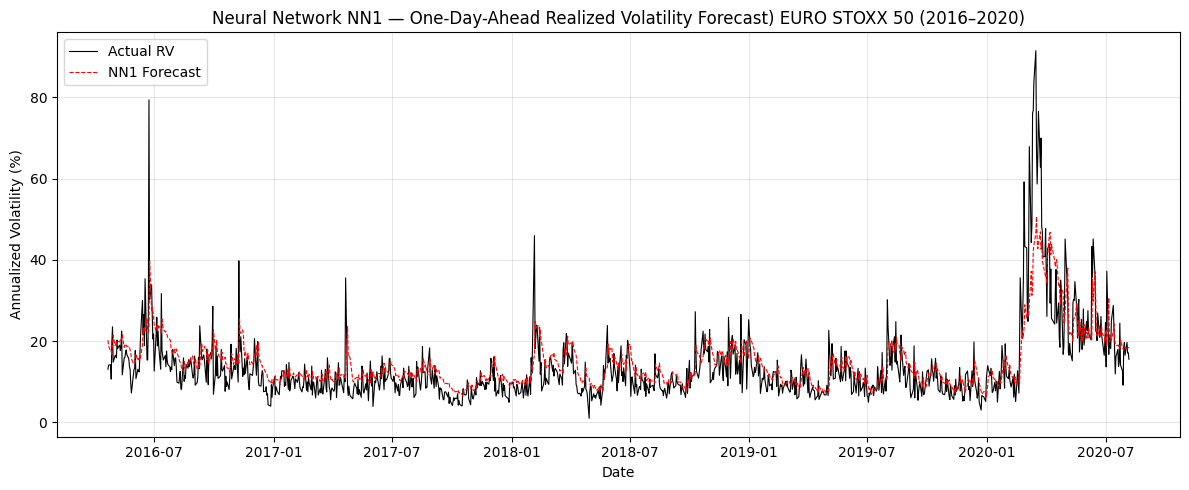

Summary of forecast errors:
Mean error:  6.085297e-06
RMSE:        1.883720e-04
MAE:         6.234145e-05


In [36]:
results_plot_NN1 = pd.DataFrame({
    "Actual": np.sqrt(results_NN1["RV_actual"] * 252) * 100,
    "Forecast": np.sqrt(results_NN1["RV_forecast"] * 252) * 100
}, index=results_NN1.index)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(results_plot_NN1["Actual"], label="Actual RV", color="black", linewidth=0.8)
ax.plot(results_plot_NN1["Forecast"], label="NN1 Forecast", color="red", linewidth=0.8, linestyle="--")
ax.set_title("Neural Network NN1 — One-Day-Ahead Realized Volatility Forecast) EURO STOXX 50 (2016–2020)", fontsize=12)
ax.set_ylabel("Annualized Volatility (%)")
ax.set_xlabel("Date")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Summary of forecast errors:")
print(f"Mean error:  {errors_NN1.mean():.6e}")
print(f"RMSE:        {np.sqrt(mse_NN1):.6e}")
print(f"MAE:         {errors_NN1.abs().mean():.6e}")


## 10. Departure Summary

To close the notebook, we summarize the differences between this thesis implementation and the exact design in the reference paper. The architecture and the core regularization devices follow the paper closely, but the estimation strategy is lighter and more adaptive because of computational constraints and the desire to let the network incorporate more recent data during the test period.

In [39]:
departure_summary = pd.DataFrame({
    "Component": [
        "Architecture",
        "Learning rate",
        "Dropout keep rate",
        "Initializer",
        "Ensemble size",
        "Networks averaged",
        "Max epochs",
        "Patience",
        "Estimation window"
    ],
    "Paper": [
        "1 hidden layer, 2 neurons",
        "0.001",
        "0.8",
        "Glorot normal",
        "100",
        "10 best",
        "500",
        "100",
        "Fixed window"
    ],
    "This thesis": [
        "1 hidden layer, 2 neurons",
        "0.001",
        "0.8",
        "Glorot normal",
        str(n_ensemble),
        str(n_best),
        str(max_epochs),
        str(patience),
        f"22-day rolling refit"
    ]
})

display(departure_summary)


,Component,Paper,This thesis
0,Architecture,"1 hidden layer, 2 neurons","1 hidden layer, 2 neurons"
1,Learning rate,0.001,0.001
2,Dropout keep rate,0.8,0.8
3,Initializer,Glorot normal,Glorot normal
4,Ensemble size,100,10
5,Networks averaged,10 best,3
6,Max epochs,500,200
7,Patience,100,50
8,Estimation window,Fixed window,22-day rolling refit
